## Imports

In [ ]:
import json
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd 
import numpy as np

# ER Comparison
from scipy import stats
from tqdm import trange

# Community detection
from networkx.algorithms.community import louvain_communities
from collections import defaultdict
from collections import Counter

# Node classification
from node2vec import Node2Vec
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

## Dataset

We use the Congressional Twitter network dataset provided by Fink et al. (2023):

- Nodes: members of the U.S. Congress represented by their Twitter accounts
- Directed edges: 𝑖→𝑗 indicates a potential influence from user 𝑖 to user 𝑗 on Twitter
- Edge weights: represent transmission probabilities, i.e., the likelihood that information spreads from node 𝑖 to node 𝑗
- Node attributes: each node is associated with a Twitter username
- Ground-truth communities: not explicitly provided and therefore inferred using community detection (Louvain algorithm)

## Research Question
**To what extent can node embeddings capture community structure in a weighted, directed social network, and which embedding approach (Node2Vec vs. Graphlet Degree Vectors) provides the most informative features for node classification tasks?**

## Methodology

We address this research question through the following steps:

- **Network preprocessing and descriptive analysis**: loading the graph, computing basic statistics, and analyzing degree distributions and connectivity  
- **Structural analysis**: clustering coefficients, transitivity, bridge detection, and centrality measures  
- **Benchmarking against a null model**: comparison with an Erdős–Rényi random graph  
- **Community detection**: extracting latent communities using the Louvain method  
- **Node classification framework**:
  - learning node representations with Node2Vec  
  - extracting structural features with Graphlet Degree Vectors (GDV)  
  - comparing classification performance across approaches  

In [8]:
# load the network

G = nx.read_edgelist(
    "congress.edgelist",
    create_using=nx.DiGraph(),
    nodetype=int
)

In [9]:
# map twitter nickname to each node

with open("congress_network_data.json") as f:
    data = json.load(f)

data = data[0]  
username_list = data["usernameList"]
node_to_username = dict(enumerate(username_list))

nx.set_node_attributes(G, node_to_username, "label")

## Empirical network: summary statistics

In [10]:
# summary statistics

def describe_graph(G):
    N = G.number_of_nodes()
    L = G.number_of_edges()
    density = nx.density(G)
    strongly_connected = nx.is_strongly_connected(G)
    num_selfloops = nx.number_of_selfloops(G) if G.is_directed() else sum(1 for u,v in G.edges() if u==v)
    isolates = nx.number_of_isolates(G)
    global_reciprocity = nx.reciprocity(G)

    if G.is_directed():
        avg_in = np.mean(list(dict(G.in_degree()).values()))
        avg_out = np.mean(list(dict(G.out_degree()).values()))
        avgs = {"avg_in": avg_in, "avg_out": avg_out}
    else:
        avg = np.mean(list(dict(G.degree()).values()))
        avgs = {"avg": avg}
    return {
        "Nodes": N, "Edges": L, 
        "density": density, **avgs,
        "Strongly connected?": strongly_connected,
        "self_loops": num_selfloops,
        "isolates": isolates,
        "Global reciprocity": global_reciprocity
    }
    
describe_graph(G)

{'Nodes': 475,
 'Edges': 13289,
 'density': 0.05902287363979569,
 'avg_in': 27.97684210526316,
 'avg_out': 27.97684210526316,
 'Strongly connected?': False,
 'self_loops': 0,
 'isolates': 0,
 'Global reciprocity': 0.4615847693581157}

The Twitter Interaction Network for the US Congress consists of 475 nodes and 13289 directed links, indicating a relatively well-connected interaction structure. With an average in-degree and out-degree of approximately 27.98, each account maintains relations with several others, suggesting a diversified pattern of exchanges within the network. The density (0.06) reflects a relatively sparse network, which is typical of social networks, where only a small fraction of all possible connections actually occurs. No self-loops were found, and the absence of isolates indicates that every node participates in the interactions.

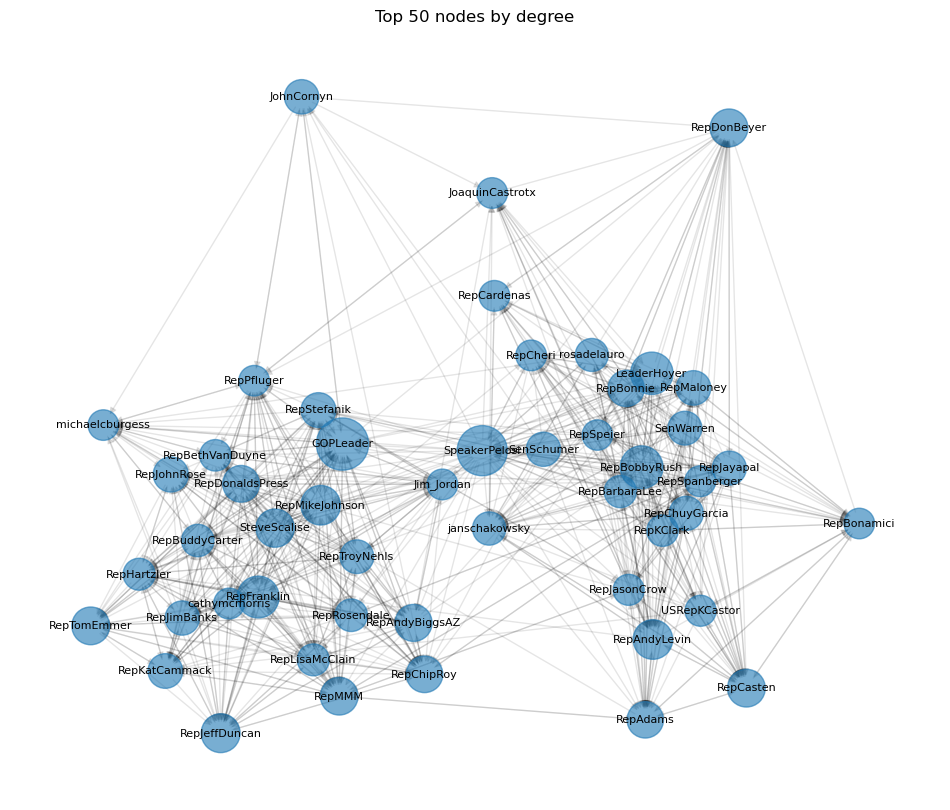

In [11]:
# Visualization: first 50 nodes by total degree

deg_dict = dict(G.degree())
top_nodes = sorted(deg_dict, key=deg_dict.get, reverse=True)[:50]

G_top = G.subgraph(top_nodes).copy()

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_top, seed=42)

nx.draw_networkx_nodes(
    G_top, pos,
    node_size=[G.degree(n) * 5 for n in G_top.nodes()],
    alpha=0.6
)

nx.draw_networkx_edges(
    G_top, pos,
    alpha=0.1,
    arrows=True,
)

nx.draw_networkx_labels(
    G_top, pos,
    labels={n: G.nodes[n].get("label", n) for n in G_top.nodes()},
    font_size=8
)

plt.title("Top 50 nodes by degree")
plt.axis("off")
plt.show()

This figure shows the subnetwork induced by the 50 nodes with the highest degree, with node size depending on their total degree. Several highly connected actors appear at the center of the structure, indicating that interactions are concentrated around a relatively small group of prominent accounts. The largest nodes, including SpeakerPelosi, GOPLeader, LeaderHoyer, and RepBobbyRush, function as hubs.

The visualization highlights a dense core of highly connected actors surrounded by more peripheral nodes, such as JohnCornyn and RepDonBeyer. This core–periphery structure suggests that a large share of interactions occurs among a relatively small set of central accounts.

Finally, some nodes appear positioned between clusters, suggesting that they may play a bridging role between different parts of the network (e.g., janschakowsky, JimJordan, RepChipRoy).

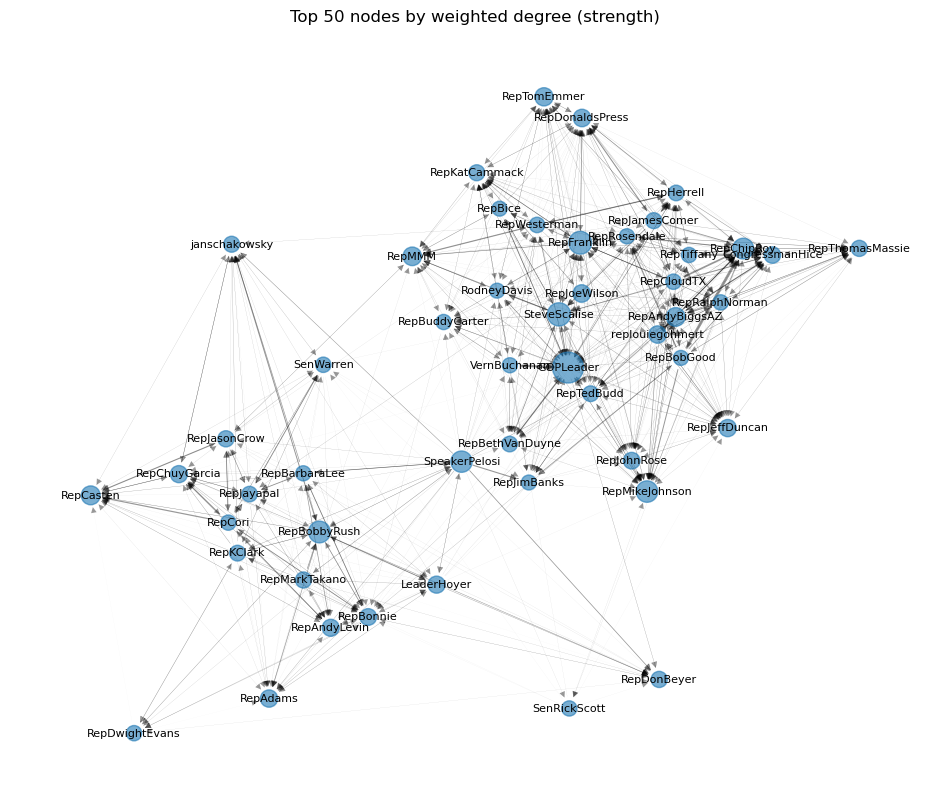

In [8]:
# plot 50 nodes by weighted degree
strength_dict = dict(G.degree(weight="weight"))

top_nodes = sorted(strength_dict, key=strength_dict.get, reverse=True)[:50]
G_top = G.subgraph(top_nodes).copy()

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_top, seed=42)

nx.draw_networkx_nodes(
    G_top, pos,
    node_size=[strength_dict[n] * 200 for n in G_top.nodes()],
    alpha=0.6
)

nx.draw_networkx_edges(
    G_top, pos,
    width=[G_top[u][v].get("weight", 1) * 20 for u, v in G_top.edges()],
    alpha=0.4,
    arrows=True
)

nx.draw_networkx_labels(
    G_top, pos,
    labels={n: G.nodes[n].get("label", n) for n in G_top.nodes()},
    font_size=8
)

plt.title("Top 50 nodes by weighted degree (strength)")
plt.axis("off")
plt.show()

This visualization shows the 50 nodes with the highest weighted degree (strength), where node size is proportional to the sum of the weights of their connections. The overall structure is consistent with the previous degree-based visualization: a dense core of highly connected actors emerges at the center of the network. Prominent nodes such as SpeakerPelosi, SteveScalise, and GOPLeader remain among the most central actors, indicating that they not only interact with many accounts but also concentrate a large share of the interaction volume. This confirms that a relatively small group of accounts dominates both the number and the intensity of interactions in the network.
As seen before, some nodes also appear positioned between clusters (e.g., janschakowsky, JimJordan, RepChipRoy), suggesting that they may play a bridging role between different parts of the network.

Nodes: 83
Edges: 50


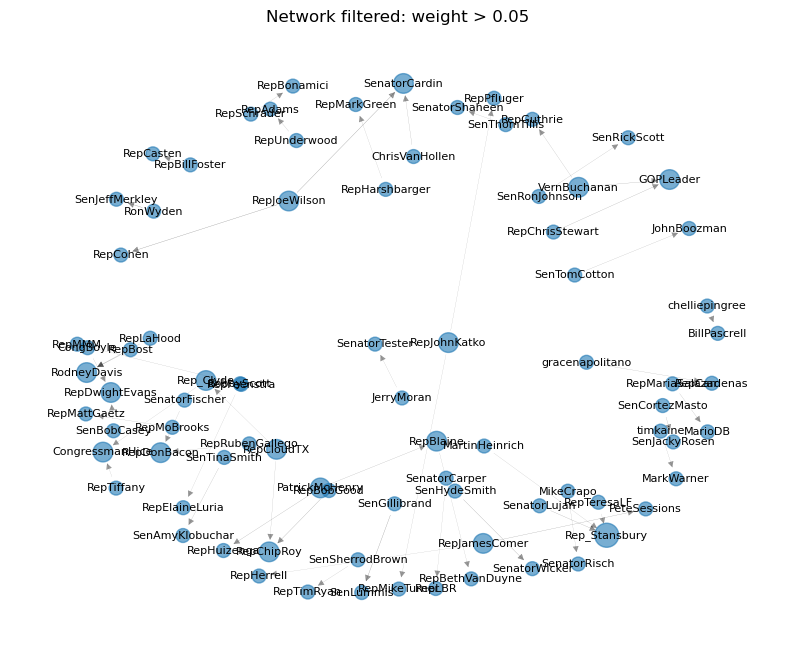

In [9]:
# plot of edges with weight > 0.05
edges_keep = [(u, v) for u, v, d in G.edges(data=True) if d.get("weight", 0) > 0.05]

# crea un nuovo grafo filtrato
G_filt = nx.DiGraph()
G_filt.add_nodes_from(G.nodes(data=True))
G_filt.add_edges_from((u, v, G[u][v]) for u, v in edges_keep)

# rimuovi nodi isolati
G_filt.remove_nodes_from(list(nx.isolates(G_filt)))

print("Nodes:", G_filt.number_of_nodes())
print("Edges:", G_filt.number_of_edges())

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G_filt, seed=42)

nx.draw_networkx_nodes(
    G_filt, pos,
    node_size=[G_filt.degree(n)*100 for n in G_filt.nodes()],
    alpha=0.6
)

nx.draw_networkx_edges(
    G_filt, pos,
    width=[G_filt[u][v]["weight"]*2 for u,v in G_filt.edges()],
    alpha=0.4,
    arrows=True
)

nx.draw_networkx_labels(
    G_filt, pos,
    labels={n: G_filt.nodes[n].get("label", n) for n in G_filt.nodes()},
    font_size=8
)

plt.title("Network filtered: weight > 0.05")
plt.axis("off")
plt.show()


This visualization shows the network after filtering edges with weight greater than 0.05, retaining only relatively strong interactions. Compared with the previous graphs, the network becomes much sparser and breaks into smaller clusters of actors who interact more frequently with each other. This filtering highlights the strongest relationships in the network and reduces the influence of weaker or sporadic interactions, making the underlying interaction structure more visible.

In force-directed layouts, nodes with connections to multiple parts of the network tend to be positioned near the center of the visualization. Accordingly, actors located in the central region of the graph (e.g., SenatorTester) likely interact with several different clusters, potentially facilitating interactions between otherwise more separated groups. Conversely, nodes located at the periphery tend to interact mainly within a smaller subset of actors.


## Connectivity

In [9]:
# Weakly and strongly connected components
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)
wcc_sizes = []
for c in wcc:
    wcc_sizes.append(len(c))
wcc_sizes = sorted(wcc_sizes,reverse=True)

scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)

print(f"Number of weakly connected components: {len(wcc)}")
print(f"    Sizes of the 5 largest WCCs: {wcc_sizes[:5]}")

print(f"Number of strongly connected components: {len(scc)}")
print(f"    Sizes of the 5 largest SCCs: {scc_sizes[:5]}")

Number of weakly connected components: 1
    Sizes of the 5 largest WCCs: [475]
Number of strongly connected components: 7
    Sizes of the 5 largest SCCs: [469, 1, 1, 1, 1]


The network consists of a single weakly connected component including all 475 nodes, meaning that the graph is fully connected once edge directions are ignored. With respect to strong connectivity, the graph splits into 7 strongly connected components. The largest strongly connected component contains 469 nodes, while the remaining 6 components are isolated single-node components.

## Degree Distribution

In [ ]:
# Compute in-degree and out-degree
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

deg_df = pd.DataFrame({
    "node": list(G.nodes()),
    "nickname": [G.nodes[n].get("label", n) for n in G.nodes()],    
    "in_degree": [in_degrees[n] for n in G.nodes()],
    "out_degree": [out_degrees[n] for n in G.nodes()]
})
deg_df["total_degree"] = deg_df["in_degree"] + deg_df["out_degree"]

deg_df.sort_values("total_degree", ascending=False).head()

,node,nickname,in_degree,out_degree,total_degree
270,322,GOPLeader,127,157,284
121,367,SpeakerPelosi,51,210,261
88,393,RepBobbyRush,79,111,190
51,254,LeaderHoyer,108,79,187
313,208,RepFranklin,121,61,182


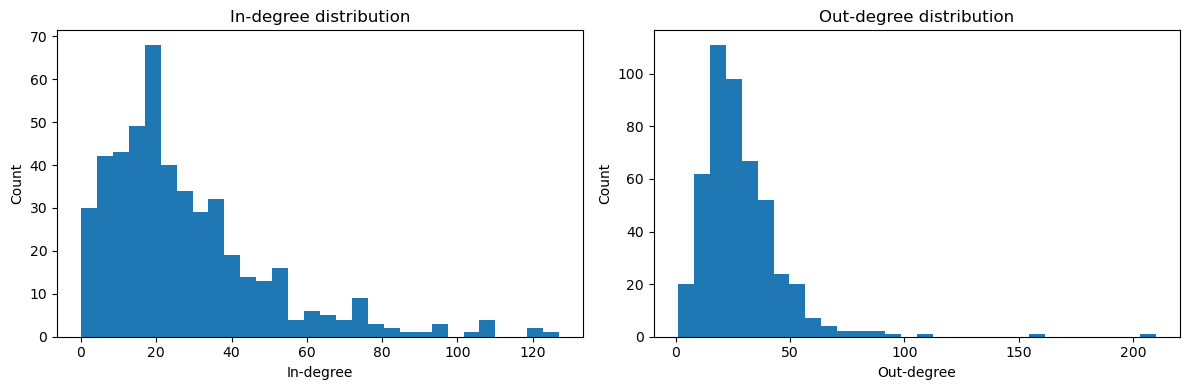

In [13]:
# Plot in-degree and out-degree distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(deg_df["in_degree"], bins=30)
axes[0].set_title("In-degree distribution")
axes[0].set_xlabel("In-degree")
axes[0].set_ylabel("Count")

axes[1].hist(deg_df["out_degree"], bins=30)
axes[1].set_title("Out-degree distribution")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

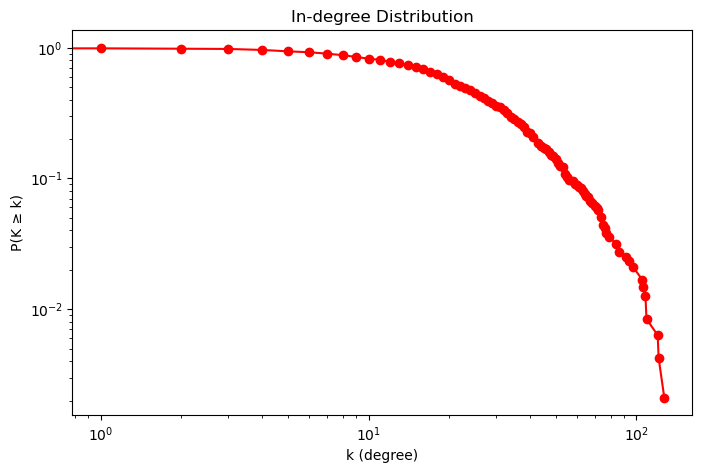

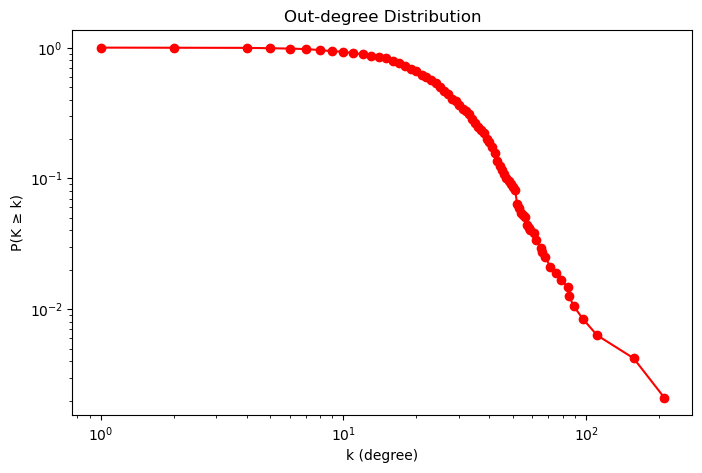

In [13]:
#log-log CCDF

def degree_sequence(G, mode="total"):
    if not G.is_directed():
        return np.array([d for _, d in G.degree()], dtype=int)

    if mode == "in":
        return np.array([d for _, d in G.in_degree()], dtype=int)

    elif mode == "out":
        return np.array([d for _, d in G.out_degree()], dtype=int)

    elif mode == "total":
        return np.array([G.in_degree(n) + G.out_degree(n) for n in G.nodes()], dtype=int)
    
in_deg = degree_sequence(G, "in")
out_deg = degree_sequence(G, "out")
tot_deg = degree_sequence(G, "total")

def plot_degree_ccdf(deg, title):
    
    deg = np.array(deg)
    x = np.sort(np.unique(deg))
    
    ccdf = [(deg >= k).sum() / len(deg) for k in x]
    
    plt.figure(figsize=(8,5))
    plt.loglog(x, ccdf, 'o-', color='red')
    
    plt.xlabel("k (degree)")
    plt.ylabel("P(K ≥ k)")
    plt.title(title)
    
    plt.show()

plot_degree_ccdf(in_deg, "In-degree Distribution")
plot_degree_ccdf(out_deg, "Out-degree Distribution")

The distributions of in-degree and out-degree describe how interactions are distributed among nodes in the directed network. Both distributions are strongly right-skewed: most nodes maintain relatively few connections, while a small number of actors exhibit very high degree values. This pattern indicates a heterogeneous structure in which a limited set of nodes concentrates a large share of the interactions.

The log–log CCDF of the degree distribution further highlights this heterogeneity, showing a heavy-tailed pattern in which a small fraction of nodes reaches very high connectivity levels compared to the rest of the network.

The table of top nodes confirms this concentration: accounts such as GOPLeader, SpeakerPelosi, RepBobbyRush, and LeaderHoyer appear among the nodes with the highest total degree. These actors combine high levels of received interactions (in-degree) and initiated interactions (out-degree), highlighting their central role in the network’s interaction structure

## Comparison with an Erdős–Rényi Null Model

To assess whether the observed degree structure could arise purely from random linking, we compare the real network with an Erdős–Rényi (ER) random graph having the same number of nodes and expected density. We generate multiple realizations of the ER model and compute the degree CDF and the diameter of the giant component for each simulated network.

### Degree Cumulative Distribution

In [ ]:
# ER model wth the same number of nodes and edges as the real network
N, L = G.order(), G.size()
p = L / (N*(N-1)) 

N, L

# Get the largest connected component of the network
gcc_real = G.subgraph(max(nx.weakly_connected_components(G), key = len)).copy()
deg_real_sample = np.array([v for _,v in gcc_real.degree()])
cdf = stats.ecdf(deg_real_sample).cdf
x_real = np.unique(deg_real_sample)
y_real = cdf.evaluate(x_real)

print(x_real)
cdf.evaluate(x_real)

[  2   5   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21  22
  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40
  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76
  77  78  79  80  81  82  83  84  85  86  88  89  90  91  92  93  94  95
  96  97  98  99 100 103 106 108 109 110 113 115 118 119 120 121 122 123
 124 125 126 128 137 138 139 140 142 147 148 152 157 163 182 187 190 261
 284]


array([0.00210526, 0.00631579, 0.00842105, 0.01052632, 0.01263158,
       0.01684211, 0.02526316, 0.02947368, 0.03789474, 0.04210526,
       0.04631579, 0.05263158, 0.05473684, 0.06526316, 0.06947368,
       0.07578947, 0.08631579, 0.09473684, 0.11157895, 0.12      ,
       0.14105263, 0.15157895, 0.16      , 0.17684211, 0.19789474,
       0.20842105, 0.22315789, 0.23368421, 0.26315789, 0.28      ,
       0.30105263, 0.32      , 0.33894737, 0.36      , 0.38315789,
       0.38947368, 0.40210526, 0.42315789, 0.43368421, 0.44210526,
       0.45263158, 0.46526316, 0.48631579, 0.50105263, 0.52210526,
       0.53263158, 0.54947368, 0.56210526, 0.57052632, 0.58315789,
       0.59578947, 0.60631579, 0.61473684, 0.62315789, 0.63157895,
       0.64631579, 0.65894737, 0.68      , 0.68631579, 0.69894737,
       0.72421053, 0.73263158, 0.74315789, 0.74736842, 0.75157895,
       0.76210526, 0.76631579, 0.77263158, 0.77894737, 0.78315789,
       0.79368421, 0.80210526, 0.80421053, 0.80631579, 0.80842

In [22]:
# Generate 300 realizations of the random model
M = 300 
CDF_er_matrix = []
for _ in trange(M, leave = False):
    G_er = nx.fast_gnp_random_graph(N,p, directed = True)
    if G_er.size == 0:
        continue
    gcc_g_er = G_er.subgraph(max(nx.weakly_connected_components(G_er), key = len)).copy()
    deg_g_er = np.array([v for _,v in gcc_g_er.degree()])
    cdf = stats.ecdf(deg_g_er).cdf
    cdf_g_er = cdf.evaluate(x_real)
    CDF_er_matrix.append(cdf_g_er)
CDF_er_matrix = np.array(CDF_er_matrix)

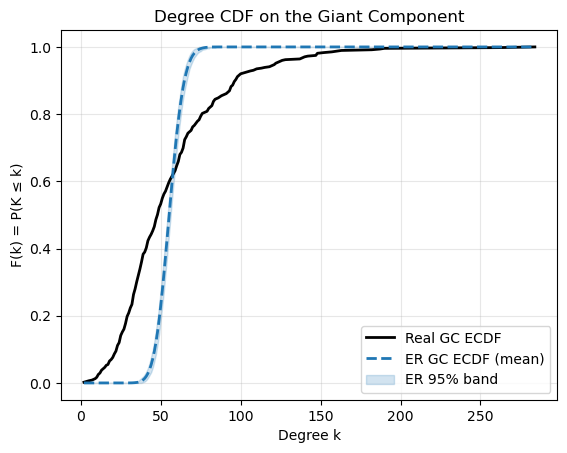

In [ ]:
# degree cdf of the giant component

F_mean = CDF_er_matrix.mean(axis=0)
F_low  = np.quantile(CDF_er_matrix, 0.025, axis=0)
F_high = np.quantile(CDF_er_matrix, 0.975, axis=0)

plt.plot(x_real, y_real, 'k-', lw=2, label='Real GC ECDF')
plt.plot(x_real, F_mean, 'C0--', lw=2, label='ER GC ECDF (mean)')
plt.fill_between(x_real, F_low, F_high, color='C0', alpha=0.2, label='ER 95% band')
plt.xlabel('Degree k'); plt.ylabel('F(k) = P(K ≤ k)')
plt.title('Degree CDF on the Giant Component')
plt.legend();
plt.grid(True, alpha=0.3); 

In [29]:
ks_vs_mean = np.array([stats.ks_2samp(CDF_er_matrix[i], F_mean).statistic for i in range(len(CDF_er_matrix))])
p_ks = (ks_vs_mean >= stats.ks_2samp(y_real, F_mean).statistic).mean()
print(f"p-value (ECDF on GC): {p_ks:.4f}")

p-value (ECDF on GC): 0.0000


### Giant Component Diameter

In [36]:
# diameter of the real giant component

diam_real = nx.diameter(gcc_real.to_undirected())
print(f"Diameter of the real giant component: {diam_real}")

# diameters in the ER ensemble
M = 300
diam_ers = []

for _ in range(M):
    G_er = nx.fast_gnp_random_graph(N, p, directed=True)
    gcc_er = G_er.subgraph(max(nx.weakly_connected_components(G_er), key=len)).copy()
    diam_er = nx.diameter(gcc_er.to_undirected())
    diam_ers.append(diam_er)

diam_ers = np.array(diam_ers)

# empirical p-value: probability under ER of observing diameter >= real one
p_val_diam = np.mean(diam_ers >= diam_real)
print(f"P-value for the diameter: {p_val_diam:.4g}")

# ECDF of ER diameters
cdf = stats.ecdf(diam_ers).cdf
x = np.unique(diam_ers)
y = cdf.evaluate(x)

# summary
ER_real_summary = pd.DataFrame({
    "Metric": [
        "Real GC diameter",
        "ER GC diameter (mean)",
        "ER GC diameter (min)",
        "ER GC diameter (max)",
        "ER GC diameter (std)",
        "Empirical p-value"
    ],
    "Value": [
        diam_real,
        np.mean(diam_ers),
        np.min(diam_ers),
        np.max(diam_ers),
        np.std(diam_ers),
        p_val_diam
    ]
})

ER_real_summary

Diameter of the real giant component: 4
P-value for the diameter: 0


,Metric,Value
0,Real GC diameter,4.0
1,ER GC diameter (mean),3.0
2,ER GC diameter (min),3.0
3,ER GC diameter (max),3.0
4,ER GC diameter (std),0.0
5,Empirical p-value,0.0


The empirical degree CDF of the giant component clearly deviates from the ER confidence band, showing a heavier upper tail and indicating a higher presence of highly connected nodes than expected under random linking. The Kolmogorov–Smirnov test further confirms this result, yielding a near-zero p-value and providing strong statistical evidence that the degree distribution of the real network cannot be explained by the Erdős–Rényi null model.

The diameter analysis provides additional evidence of structural differences: the diameter of the real giant component is 4, while the ER ensemble consistently produces a smaller diameter (3). This suggests that the real network is less homogeneous and exhibits a more structured connectivity pattern than predicted by the ER null model.

Overall, these results indicate that the network organization cannot be explained by purely random interactions, but instead reflects structural heterogeneity and the presence of hubs.

## Clustering coefficient

In [15]:
# Convert to undirected for clustering measures
G_und = G.to_undirected()

# Compute global metrics
global_clustering = nx.transitivity(G_und)
avg_local_clustering = nx.average_clustering(G_und)

print(f"Global clustering coefficient (transitivity): {global_clustering:.4f}")
print(f"Average local clustering: {avg_local_clustering:.4f}")

Global clustering coefficient (transitivity): 0.2695
Average local clustering: 0.3014


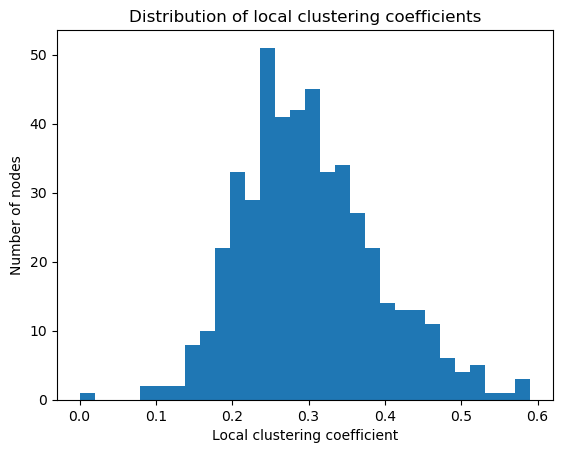

In [16]:
# Distribution of local clustering coefficients

clustering_dict = nx.clustering(G_und)
clustering_values = list(clustering_dict.values())

plt.hist(clustering_values, bins=30)
plt.xlabel("Local clustering coefficient")
plt.ylabel("Number of nodes")
plt.title("Distribution of local clustering coefficients")
plt.show()

To compute clustering measures, the network was converted to an undirected graph. The global clustering coefficient (transitivity) is 0.2695, indicating a moderate tendency for nodes to form closed triangles. The average local clustering coefficient (0.3014) suggests that, on average, the neighbors of a node are relatively likely to be connected with each other.

The distribution of local clustering coefficients shows that most nodes have values between approximately 0.2 and 0.4, indicating a moderate level of local cohesiveness in the network. This suggests that interactions often occur within small groups of interconnected actors rather than being completely random.

## Bridges

In [17]:
# Compute bridges on undirected graph
bridges = list(nx.bridges(G_und))
print(f"Number of bridges in the undirected graph: {len(bridges)} ({round(len(bridges)/G_und.size()*100,2)}% of edges)")

# Compute bridges
local_bridges = list(nx.local_bridges(G_und, with_span = False))
print(f"Number of local bridges in the undirected graph: {len(local_bridges)} - ({round(len(local_bridges)/G_und.size()*100,2)}% of edges)")

# Table
local_bridges_df = pd.DataFrame(local_bridges, columns=["node_u", "node_v"])
local_bridges_df["label_u"] = local_bridges_df["node_u"].apply(lambda n: G.nodes[n].get("label", n))
local_bridges_df["label_v"] = local_bridges_df["node_v"].apply(lambda n: G.nodes[n].get("label", n))
local_bridges_df = local_bridges_df[["node_u", "label_u", "node_v", "label_v"]]

local_bridges_df.head(10)

Number of bridges in the undirected graph: 0 (0.0% of edges)
Number of local bridges in the undirected graph: 94 - (0.92% of edges)


,node_u,label_u,node_v,label_v
0,18,SenCortezMasto,217,RepSylviaGarcia
1,58,ChrisMurphyCT,381,RepKathleenRice
2,76,SenTinaSmith,336,RepCarolMiller
3,341,RepGwenMoore,419,RepSmucker
4,17,JohnCornyn,152,RepLizCheney
5,79,SenatorTester,396,RepMariaSalazar
6,79,SenatorTester,407,AustinScottGA08
7,213,RepGaramendi,240,RepJoshHarder
8,250,jahimes,69,marcorubio
9,250,jahimes,406,RepDavid


The undirected network contains no bridges, indicating that no single edge is structurally critical for maintaining global connectivity. This suggests a highly redundant structure with multiple alternative paths between nodes. However, 94 local bridges (0.92% of edges) are present, representing ties that connect otherwise unshared neighborhoods and potentially linking different communities.

The table above shows some examples of these ties. Among them, JohnCornyn was already identified among the nodes with the highest total degree, while SenatorTester appeared in a relatively central position in the filtered network visualization (weight > 0.05). Their presence among the local bridges suggests that some highly connected or structurally central actors may also participate in ties that link otherwise weakly connected parts of the network.

Interestingly, several of the local bridges involve nodes whose labels suggest membership in different chambers of Congress. In particular, a number of edges connect accounts labeled with the prefix Sen (senators) to accounts labeled with Rep (representatives). This pattern may indicate interactions that link actors from the Senate and the House of Representatives, potentially contributing to connectivity across different institutional groups.

## Centrality Measures

In [18]:
# Degree centrality (undirected)
deg_cent = nx.degree_centrality(G_und)

# Betweenness centrality (undirected)
bet_cent = nx.betweenness_centrality(G_und, normalized=True)

# Closeness centrality (undirected)
clo_cent = nx.closeness_centrality(G_und)

# PageRank (directed)
pr = nx.pagerank(G, alpha=0.85)

# In-degree and out-degree
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

# Node labels (twitter usernames)
labels = nx.get_node_attributes(G, "label")

# Build centrality dataframe
centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "label": [labels.get(n, n) for n in G.nodes()],
    "degree_centrality": [deg_cent[n] for n in G.nodes()],
    "betweenness_centrality": [bet_cent[n] for n in G.nodes()],
    "closeness_centrality": [clo_cent[n] for n in G.nodes()],
    "pagerank": [pr[n] for n in G.nodes()],
    "in_degree": [in_deg[n] for n in G.nodes()],
    "out_degree": [out_deg[n] for n in G.nodes()]
})

centrality_df.sort_values("pagerank", ascending=False).head(10)

,node,label,degree_centrality,betweenness_centrality,closeness_centrality,pagerank,in_degree,out_degree
270,322,GOPLeader,0.381857,0.037183,0.617188,0.016696,127,157
81,147,RepCasten,0.219409,0.007614,0.549247,0.012845,97,51
105,389,RepChipRoy,0.194093,0.005526,0.547977,0.011028,84,55
298,269,RepMikeJohnson,0.236287,0.007737,0.555035,0.010660,106,57
84,215,RepChuyGarcia,0.177215,0.004055,0.544202,0.010580,76,45
313,208,RepFranklin,0.282700,0.015459,0.570397,0.008885,121,61
126,92,RepAdams,0.221519,0.013185,0.558304,0.008246,94,44
101,246,CongressmanHice,0.132911,0.002414,0.522602,0.008157,59,29
207,303,RepAndyLevin,0.217300,0.009322,0.546713,0.008033,97,66
287,113,RepAndyBiggsAZ,0.204641,0.007742,0.551163,0.008026,77,65


The table reports several centrality measures for the nodes in the network, including degree centrality, betweenness centrality, closeness centrality, and PageRank. Nodes are ranked according to their PageRank score, which reflects the structural importance of actors in the directed network by taking into account both the number and the importance of incoming connections.

The results highlight several prominent actors, including GOPLeader, RepCasten, and RepChipRoy (all right-wing politicians), which appear among the nodes with the highest PageRank values. In particular, GOPLeader shows the highest PageRank and also exhibits high values in degree centrality and betweenness centrality, suggesting a structurally central role in the network. The presence of several Republican accounts may indicate that some actors from this political group play a prominent role in the interaction structure of the network. This could reflect differences in communication patterns or interaction dynamics within the dataset.

In [ ]:
# Key nodes
def show_top(df, col, k=10):
    print(f"\nTop {k} nodes by {col}:")
    display(
        df.sort_values(col, ascending=False)
          .reset_index(drop=True)
          .head(k)[["node", "label", col, "in_degree", "out_degree"]]
    )

show_top(centrality_df, "degree_centrality")
show_top(centrality_df, "betweenness_centrality")
show_top(centrality_df, "closeness_centrality")
show_top(centrality_df, "pagerank")


Top 10 nodes by degree_centrality:


,node,label,degree_centrality,in_degree,out_degree
0,367,SpeakerPelosi,0.451477,51,210
1,322,GOPLeader,0.381857,127,157
2,254,LeaderHoyer,0.299578,108,79
3,208,RepFranklin,0.282700,121,61
4,393,RepBobbyRush,0.272152,79,111
5,190,RepJeffDuncan,0.267932,120,37
6,111,RepDonBeyer,0.253165,109,39
7,192,RepTomEmmer,0.238397,105,43
8,269,RepMikeJohnson,0.236287,106,57
9,385,RepJohnRose,0.234177,108,20



Top 10 nodes by betweenness_centrality:


,node,label,betweenness_centrality,in_degree,out_degree
0,367,SpeakerPelosi,0.068626,51,210
1,322,GOPLeader,0.037183,127,157
2,254,LeaderHoyer,0.022623,108,79
3,208,RepFranklin,0.015459,121,61
4,17,JohnCornyn,0.014895,72,51
5,71,SenSchumer,0.013771,25,97
6,393,RepBobbyRush,0.013559,79,111
7,461,RepBonnie,0.013285,75,62
8,92,RepAdams,0.013185,94,44
9,190,RepJeffDuncan,0.013048,120,37



Top 10 nodes by closeness_centrality:


,node,label,closeness_centrality,in_degree,out_degree
0,367,SpeakerPelosi,0.645777,51,210
1,322,GOPLeader,0.617188,127,157
2,254,LeaderHoyer,0.585185,108,79
3,111,RepDonBeyer,0.571084,109,39
4,393,RepBobbyRush,0.570397,79,111
5,208,RepFranklin,0.570397,121,61
6,461,RepBonnie,0.561611,75,62
7,92,RepAdams,0.558304,94,44
8,190,RepJeffDuncan,0.557647,120,37
9,71,SenSchumer,0.556338,25,97



Top 10 nodes by pagerank:


,node,label,pagerank,in_degree,out_degree
0,322,GOPLeader,0.016696,127,157
1,147,RepCasten,0.012845,97,51
2,389,RepChipRoy,0.011028,84,55
3,269,RepMikeJohnson,0.010660,106,57
4,215,RepChuyGarcia,0.010580,76,45
5,208,RepFranklin,0.008885,121,61
6,92,RepAdams,0.008246,94,44
7,246,CongressmanHice,0.008157,59,29
8,303,RepAndyLevin,0.008033,97,66
9,113,RepAndyBiggsAZ,0.008026,77,65


An interesting point emerges when comparing the various centrality measures. SpeakerPelosi ranks highest in degree, betweenness, and closeness centrality, indicating a very central structural position in the network. However, GOPLeader obtains the highest PageRank score. Since PageRank takes the direction of interactions into account, this result suggests that GOPLeader receives attention from other influential actors in the network. 

A closer look at the in-degree and out-degree values helps explain this difference. SpeakerPelosi shows a very high out-degree, indicating a highly active account that interacts with many others in the network. In contrast, GOPLeader receives a larger number of incoming interactions, which contributes to its higher PageRank score. This pattern suggests that while SpeakerPelosi plays a very active role in the interaction structure, GOPLeader occupies a more prominent position as a recipient of interactions from other actors.This distinction highlights how different actors may occupy different roles in the network, such as highly active participants versus highly referenced or influential nodes.

## Community Detection

In [21]:
# Louvain Community detection
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

print("Running Louvain community detection...")
louvain_comms = louvain_communities(G_und, seed=42)

print(f"Detected {len(louvain_comms)} communities.")

Running Louvain community detection...
Detected 4 communities.


In [22]:
# Node -> community mapping
community_map = {}

for i, comm in enumerate(louvain_comms):
    for node in comm:
        community_map[node] = i

centrality_df["community"] = centrality_df["node"].map(community_map)

nx.set_node_attributes(G, community_map, "community")
nx.set_node_attributes(G_und, community_map, "community")

# Save graph for GDV computation in Colab
nx.write_edgelist(G_und, "G_und.edgelist")

In [ ]:
# Dataset for ML tasks (node classification)
ml_df = pd.DataFrame({
    "node": list(community_map.keys()),
    "community": list(community_map.values())
})

ml_df.head()

,node,community
0,35,0
1,53,0
2,70,0
3,92,0
4,94,0


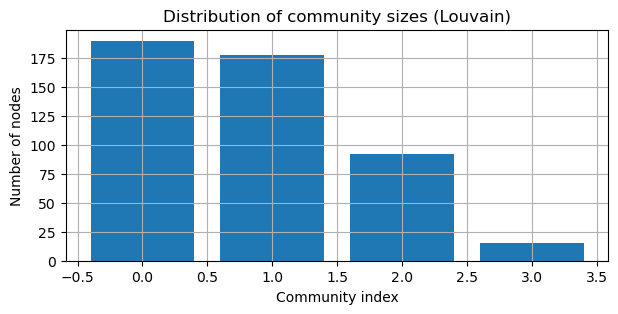

Number of communities: 4
Smallest community: 15 nodes
Largest community: 190 nodes


In [24]:
# Compute community sizes
community_sizes = sorted([len(c) for c in louvain_comms], reverse = True)

# Plot histogram
plt.figure(figsize=(7,3))
plt.bar(range(len(community_sizes)),community_sizes)
plt.xlabel("Community index")
plt.ylabel("Number of nodes")
plt.title("Distribution of community sizes (Louvain)")
plt.grid(True)
plt.show()

# Print summary stats
print(f"Number of communities: {len(community_sizes)}")
print(f"Smallest community: {min(community_sizes)} nodes")
print(f"Largest community: {max(community_sizes)} nodes")

In [32]:
# Avg centrality measures by community
community_summary = centrality_df.groupby("community").agg(
    n_nodes=("node", "count"),
    avg_pagerank=("pagerank", "mean"),
    avg_degree=("degree_centrality", "mean"),
    max_pagerank=("pagerank", "max")
).sort_values("avg_pagerank", ascending=False)

display(community_summary)

# Assortativity
assortativity = nx.attribute_assortativity_coefficient(G_und, "community")
print(f"Network assortativity: {assortativity:4f}")

,n_nodes,avg_pagerank,avg_degree,max_pagerank
community,,,,
3,178,0.002382,0.093609,0.016696
0,190,0.002204,0.095803,0.012845
2,15,0.001870,0.071027,0.005226
1,92,0.001403,0.078265,0.005677


Network assortativity: 0.608938


The Louvain community detection algorithm identifies four communities in the undirected version of the network. Two large communities dominate the structure (190 and 178 nodes), while the remaining ones are smaller (92 and 15 nodes). This indicates that most actors are grouped into a few large interaction clusters rather than many small isolated groups.

The average centrality measures by community show that communities 3 and 0 have the highest average PageRank and degree values, suggesting that many of the most central actors are located within these groups.

The assortativity coefficient with respect to community membership is 0.61, indicating a strong tendency for nodes to connect with others belonging to the same community. This confirms that interactions are highly clustered within communities rather than evenly distributed across the network.

In [27]:
# Modularity score
from networkx.algorithms.community.quality import modularity

mod_score = modularity(G_und, louvain_comms)
mod_score_w = modularity(G_und, louvain_comms, weight="weight")

print(f"Unweighted modularity score: {mod_score:.4f}")
print(f"Weighted modularity score: {mod_score_w:.4f}")

Unweighted modularity score: 0.4385
Weighted modularity score: 0.4385


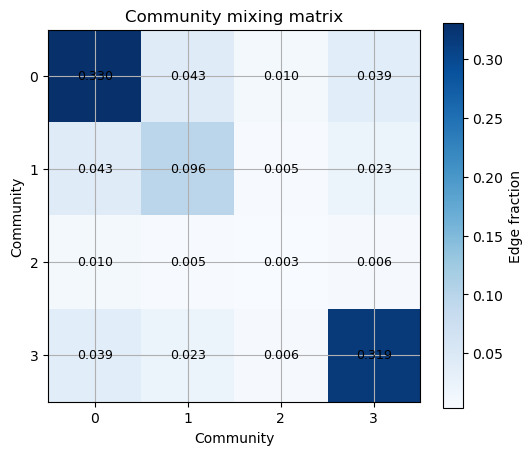

In [38]:
# Community mixing matrix: edges among communities (undirected)
mix_matrix = nx.attribute_mixing_matrix(G_und, "community")

# Heatmap
plt.figure(figsize=(6,5))

plt.imshow(mix_matrix, cmap="Blues")
plt.colorbar(label="Edge fraction")

plt.xticks(range(len(mix_matrix)), range(len(mix_matrix)))
plt.yticks(range(len(mix_matrix)), range(len(mix_matrix)))

plt.xlabel("Community")
plt.ylabel("Community")
plt.title("Community mixing matrix")

# Add numbers inside the cells
for i in range(mix_matrix.shape[0]):
    for j in range(mix_matrix.shape[1]):
        plt.text(j, i, f"{mix_matrix[i, j]:.3f}",
                 ha="center", va="center",
                 color="black", fontsize=9)

plt.show()

The Louvain partition achieves a modularity score of 0.4385, indicating a well-defined community structure. The community mixing matrix confirms this pattern, showing that most edges connect nodes within the same community rather than across communities.

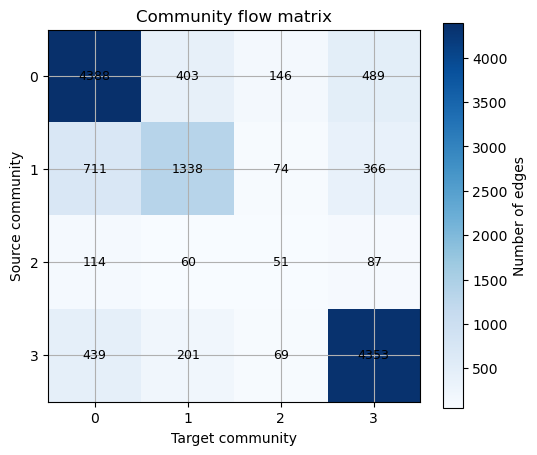

In [37]:
# Community flow matrix: edges among communities (directed)
rows = []

for u, v in G.edges():
    rows.append({
        "source_node": u,
        "source_community": G.nodes[u].get("community"),
        "target_node": v,
        "target_community": G.nodes[v].get("community")
    })

edges_comm_df = pd.DataFrame(rows)

comm_flow_matrix = pd.crosstab(
    edges_comm_df["source_community"],
    edges_comm_df["target_community"]
).sort_index().sort_index(axis=1)

# Heatmap
plt.figure(figsize=(6,5))

matrix = comm_flow_matrix.values

plt.imshow(matrix, cmap="Blues")
plt.colorbar(label="Number of edges")
plt.xticks(range(len(comm_flow_matrix.columns)), comm_flow_matrix.columns)
plt.yticks(range(len(comm_flow_matrix.index)), comm_flow_matrix.index)
plt.xlabel("Target community")
plt.ylabel("Source community")
plt.title("Community flow matrix")

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(j, i, matrix[i, j],
                 ha="center", va="center",
                 color="black", fontsize=9)

plt.show()



In [35]:
total_edges = comm_flow_matrix.values.sum()
intra_edges = comm_flow_matrix.values.diagonal().sum()

print(f"Intra-community edges: {intra_edges/total_edges:.2%}")
print(f"Inter-community edges: {(total_edges-intra_edges)/total_edges:.2%}")

Intra-community edges: 76.23%
Inter-community edges: 23.77%


The community flow matrix reports the number of directed edges connecting each pair of communities. Most interactions occur within the same community: approximately 76.23% of edges are intra-community, while 23.77% connect nodes belonging to different communities. This pattern further confirms the strong modular structure of the network, consistent with the relatively high modularity and assortativity values observed earlier. In particular, communities 0 and 3 exhibit the largest number of internal interactions, reflecting the strong internal cohesion of the two largest groups in the network.

### Inter-community Bridges

To further investigate how communities are connected, we analyze local bridges, i.e. edges whose endpoints do not share common neighbors. These edges often represent structural links between otherwise densely connected modules.

In [30]:
# Edge betweenness
edge_bet = nx.edge_betweenness_centrality(G_und, weight=None)

rows = []

for u, v, span in nx.local_bridges(G_und, with_span=True):
    
    rows.append({
        "source_node": u,
        "source_label": G_und.nodes[u].get("label", str(u)),
        "source_community": G_und.nodes[u].get("community"),
        "target_node": v,
        "target_label": G_und.nodes[v].get("label", str(v)),
        "target_community": G_und.nodes[v].get("community"),
        "same_community": G_und.nodes[u].get("community") == G_und.nodes[v].get("community"),
        "span": span,
        "edge_betweenness": edge_bet.get((u, v), edge_bet.get((v, u)))
    })

local_bridges_df = pd.DataFrame(rows)

local_bridges_df = local_bridges_df.sort_values(
    by="edge_betweenness",
    ascending=False
).reset_index(drop=True)

local_bridges_df.head(15)

,source_node,source_label,source_community,target_node,target_label,target_community,same_community,span,edge_betweenness
0,408,BobbyScott,0,395,Kilili_Sablan,0,True,3,0.002236
1,264,RepJeffries,0,395,Kilili_Sablan,0,True,3,0.001977
2,350,RepTroyNehls,3,146,RepEdCase,0,False,3,0.001176
3,229,RepJoshG,2,434,RepTomSuozzi,2,True,3,0.000928
4,175,RodneyDavis,3,366,RepDonaldPayne,0,False,3,0.000923
5,452,RepBethVanDuyne,3,463,PeterWelch,1,False,3,0.000895
6,440,RepTiffany,3,434,RepTomSuozzi,2,False,3,0.000858
7,334,RepKweisiMfume,2,426,RepPeteStauber,3,False,3,0.000830
8,5,RoyBlunt,1,242,RepHartzler,3,False,3,0.000827
9,280,RepDanKildee,0,323,RepMcCaul,3,False,3,0.000812


In [31]:
# number and percentage of local bridges linking different communities
print(local_bridges_df["same_community"].value_counts())
print(f"Percentage of local bridges connecting different communities: {1 - local_bridges_df['same_community'].mean():.4f}")

same_community
False    78
True     16
Name: count, dtype: int64
Percentage of local bridges connecting different communities: 0.8298


In [32]:
# count matrix
comm_matrix = pd.crosstab(
    local_bridges_df["source_community"],
    local_bridges_df["target_community"]
)

comm_matrix = comm_matrix.add(comm_matrix.T, fill_value=0)

comm_matrix = comm_matrix.sort_index().sort_index(axis=1)

comm_matrix.index.name = None
comm_matrix.columns.name = None

comm_matrix

,0,1,2,3
0,20,13,3,46
1,13,6,0,13
2,3,0,2,3
3,46,13,3,4


Although no global bridges are present in the network, a total of 94 local bridges were identified. The vast majority of these edges (83%) connect nodes belonging to different Louvain communities, indicating that they function as structural links between otherwise densely connected modules. 

While the edge betweenness values remain relatively small, this is expected in large and dense networks where shortest paths are distributed across many alternative routes. The community × community matrix further clarifies the distribution of these bridges: most cross-community links occur between communities 0 and 3, indicating that these two modules form the main structural interface of the network, consistent with the earlier analysis of intra- and inter-community edges. Community 1 also maintains several connections with both communities 0 and 3, whereas community 2 appears more weakly connected to the rest of the network.

### Community-level Visualization

In [41]:
# community-level network visualization
communities = nx.get_node_attributes(G_und, "community")

community_edges = defaultdict(int)

for u, v in G_und.edges():
    cu = communities[u]
    cv = communities[v]

    if cu != cv:
        community_edges[(cu, cv)] += 1

# community graph
G_comm = nx.Graph()

for (c1, c2), w in community_edges.items():
    if G_comm.has_edge(c1, c2):
        G_comm[c1][c2]["weight"] += w
    else:
        G_comm.add_edge(c1, c2, weight=w)

sizes = Counter(communities.values())

for c in G_comm.nodes():
    G_comm.nodes[c]["size"] = sizes[c]

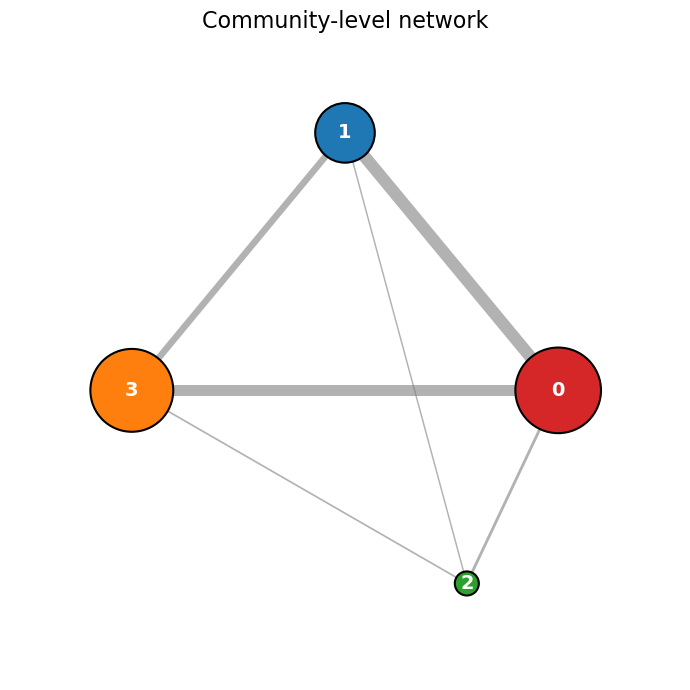

In [42]:
plt.figure(figsize=(7,7))

pos = {
    0: (0.9, 0.45),
    1: (0.55, 0.85),
    2: (0.75, 0.15),
    3: (0.2, 0.45)
}

node_sizes = [G_comm.nodes[n]['size'] * 20 for n in G_comm.nodes()]
edge_widths = [G_comm[u][v]['weight'] / 100 for u, v in G_comm.edges()]
colors = ["#1f77b4", "#2ca02c", "#d62728", "#ff7f0e"]

nx.draw_networkx_edges(
    G_comm,
    pos,
    width=edge_widths,
    edge_color="gray",
    alpha=0.6
)

nx.draw_networkx_nodes(
    G_comm,
    pos,
    node_size=node_sizes,
    node_color=colors[:len(G_comm.nodes())],
    edgecolors="black",
    linewidths=1.5
)

nx.draw_networkx_labels(
    G_comm,
    pos,
    font_size=14,
    font_weight="bold",
    font_color="white"
)

plt.title("Community-level network", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.xlim(0,1.1)
plt.ylim(0,1)
plt.show()

# Machine Learning Task: Node Classification

In this section we evaluate whether the structural position of nodes in the network can be used to predict their community membership.
The task is formulated as a node classification problem, where the label of each node corresponds to the community detected in the previous section.

To represent nodes numerically, we compare two different approaches to node representation learning:
* Node2Vec embeddings, which learn vector representations through biased random walks and a skip-gram model.
* Graphlet Degree Vectors (GDV), which explicitly describe the local structural role of each node by counting its participation in small induced subgraphs.

These two methods capture complementary aspects of the network structure. Node2Vec learns latent embeddings based on network proximity, while GDV provides an explicit structural description of local topology. Comparing them allows us to assess whether community membership is better explained by embedding similarity or by local structural patterns.

To ensure a fair comparison, the same stratified train–test split is used across all experiments. The classification model (logistic regression) and evaluation metrics remain the same; only the feature extraction method changes.

### Node2Vec embeddings
Node embeddings are learned using the Node2Vec algorithm, which generates random walks from each node and trains a skip-gram model to predict nodes appearing in the same walk context. This process places nodes with similar network neighborhoods close to each other in the embedding space.

Different Node2Vec configurations are evaluated by varying the parameter q, which controls the exploration strategy of the random walks. Larger values of 𝑞 bias the walk toward a BFS-like behavior, emphasizing local neighborhoods. Since community membership is largely determined by local connectivity patterns, this strategy is expected to improve node classification performance.

### Graphlet Degree Vectors (GDV)

To complement Node2Vec embeddings, we also consider a structural node representation based on Graphlet Degree Vectors (GDV). GDV summarizes the local topological role of each node by counting how many times it participates in different graphlet orbits (small induced subgraphs).

While Node2Vec captures node similarity through random-walk contexts, GDV explicitly characterizes local structural patterns in the network. This makes GDV a useful baseline for evaluating whether community membership is primarily explained by local topology rather than by latent embedding proximity.

In addition to GDV features, we also experiment with an extended representation that combines GDV with classical centrality measures (degree, eigenvector centrality, Katz centrality, and PageRank).

### Evaluation

For each representation method (Node2Vec, GDV, and GDV + centrality features), a logistic regression classifier is trained to predict node communities. Performance is evaluated using:
* Accuracy
* Macro F1-score
* Weighted F1-score

The results are summarized in a final comparison table to assess which representation best captures the community structure of the network.

In [43]:
# Train-test split
community_dict = dict(zip(ml_df["node"], ml_df["community"]))
nodes_ml = list(ml_df["node"])

# Save node order used for ML
pd.Series(nodes_ml).to_csv("nodes_ml.csv", index=False)

y = np.array([community_dict[node] for node in nodes_ml])

train_idx, test_idx = train_test_split(
    np.arange(len(nodes_ml)),
    test_size=0.3,
    random_state=42,
    stratify=y
)

y_train = y[train_idx]
y_test = y[test_idx]

To ensure a fair comparison across node representations, the same stratified train-test split was used for all experiments. Only the feature extraction method changed across models.

## Node2Vec embeddings & Logistic Regression

In [51]:
# Node classification using Node2Vec embeddings
# Predict the Louvain community labels using Logistic Regression

configs = [
    {"name": "baseline", "p": 1, "q": 1},
    {"name": "bfs_like_q2", "p": 1, "q": 2},
    {"name": "bfs_like_q4", "p": 1, "q": 4},
]

results = []
all_reports = {}

# Save embeddings and metadata for later analysis
embeddings_by_config = {}
nodes_by_config = {}
models_by_config = {}
predictions_by_config = {}

# Logistic Regression: loop over configurations
for cfg in configs:
    print(f"\nRunning config: {cfg['name']} (p={cfg['p']}, q={cfg['q']})")

    node2vec = Node2Vec(
        G_und,
        dimensions=64,
        walk_length=30,
        num_walks=200,
        workers=1,
        seed=42,
        p=cfg["p"],
        q=cfg["q"]
    )

    model = node2vec.fit(window=10, min_count=1)
    # node -> embedding
    embeddings = {node: model.wv[str(node)] for node in G_und.nodes()}
    X = np.array([embeddings[node] for node in nodes_ml])

    # Save for later use (PCA, t-SNE, distance analysis)
    embeddings_by_config[cfg["name"]] = X
    nodes_by_config[cfg["name"]] = list(nodes_ml)
    models_by_config[cfg["name"]] = model

    X_train = X[train_idx]
    X_test = X[test_idx]

    clf = LogisticRegression(max_iter=2000, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    predictions_by_config[cfg["name"]] = y_pred

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "config": cfg["name"],
        "p": cfg["p"],
        "q": cfg["q"],
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    })

    all_reports[cfg["name"]] = classification_report(y_test, y_pred)

    print(f"Accuracy     : {acc:.4f}")
    print(f"F1 macro     : {f1_macro:.4f}")
    print(f"F1 weighted  : {f1_weighted:.4f}")

# Summary table
results_df = pd.DataFrame(results).sort_values(
    by=["f1_macro", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("\n=== Summary of results ===")
print(results_df)

# Print full classification reports
for name, report in all_reports.items():
    print(f"\n=== Classification report: {name} ===")
    print(report)


Running config: baseline (p=1, q=1)


Computing transition probabilities:   0%|          | 0/475 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:25<00:00,  7.86it/s]


Accuracy     : 0.9720
F1 macro     : 0.9441
F1 weighted  : 0.9716

Running config: bfs_like_q2 (p=1, q=2)


Computing transition probabilities:   0%|          | 0/475 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:22<00:00,  8.90it/s]


Accuracy     : 0.9650
F1 macro     : 0.9374
F1 weighted  : 0.9646

Running config: bfs_like_q4 (p=1, q=4)


Computing transition probabilities:   0%|          | 0/475 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:23<00:00,  8.45it/s]


Accuracy     : 0.9720
F1 macro     : 0.9398
F1 weighted  : 0.9716

=== Summary of results ===
        config  p  q  accuracy  f1_macro  f1_weighted
0     baseline  1  1  0.972028  0.944090     0.971625
1  bfs_like_q4  1  4  0.972028  0.939782     0.971616
2  bfs_like_q2  1  2  0.965035  0.937399     0.964586

=== Classification report: baseline ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        57
           1       0.96      0.96      0.96        28
           2       1.00      0.75      0.86         4
           3       0.96      0.98      0.97        54

    accuracy                           0.97       143
   macro avg       0.98      0.92      0.94       143
weighted avg       0.97      0.97      0.97       143


=== Classification report: bfs_like_q2 ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        57
           1       0.96      0.93      0.95        28
       

The node classification task was performed using Node2Vec embeddings combined with a Logistic Regression classifier. Overall, the results show high predictive performance across all configurations, with accuracy values around 97% and macro-F1 scores above 0.93.

The baseline configuration (p = 1, q = 1) and the BFS-like configuration with q = 4 achieve the best performance (accuracy ≈ 0.972), while the configuration q = 2 performs slightly worse but still remains very competitive. This suggests that the learned embeddings capture the community structure of the network effectively, regardless of the specific random-walk bias.

Looking at the classification report, the model performs very well for the largest communities (0 and 3), which achieve F1-scores close to 0.98. In contrast, the smallest community (community 2) shows lower recall, likely due to the very limited number of training samples, highlighting the impact of class imbalance on classification performance.

In [47]:
# intra/inter-community distance of embedded nodes
best_config = results_df.loc[0, "config"]
print("Best Node2Vec configuration:", best_config)

X_best = embeddings_by_config[best_config]
y_best = y

dist_matrix = cosine_distances(X_best)

intra = []
inter = []

for i in range(len(X_best)):
    for j in range(i + 1, len(X_best)):
        if y_best[i] == y_best[j]:
            intra.append(dist_matrix[i, j])
        else:
            inter.append(dist_matrix[i, j])

print("Mean intra-community distance:", np.mean(intra))
print("Mean inter-community distance:", np.mean(inter))

Best Node2Vec configuration: baseline
Mean intra-community distance: 0.6898032
Mean inter-community distance: 0.8596956


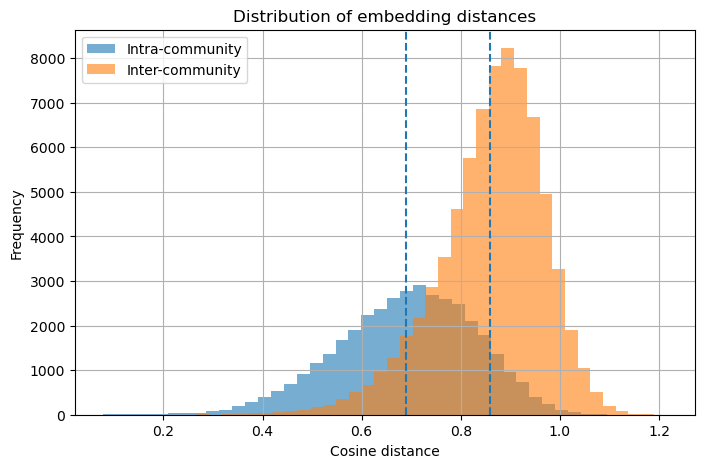

In [48]:
# distance distribution plot
plt.figure(figsize=(8,5))

plt.hist(intra, bins=40, alpha=0.6, label="Intra-community")
plt.hist(inter, bins=40, alpha=0.6, label="Inter-community")

plt.axvline(np.mean(intra), linestyle="--")
plt.axvline(np.mean(inter), linestyle="--")

plt.xlabel("Cosine distance")
plt.ylabel("Frequency")
plt.title("Distribution of embedding distances")
plt.legend()

plt.show()

To assess whether the Node2Vec embeddings capture the community structure of the network, we compare the cosine distances between node embeddings belonging to the same community and those belonging to different communities.
Using the best-performing configuration (p = 1, q = 1), the mean intra-community distance is 0.69, while the mean inter-community distance is 0.86, indicating that nodes within the same community tend to have substantially more similar embeddings than nodes from different communities.

The distribution of cosine distances further supports this result. Although some overlap between the two distributions is present, inter-community distances are clearly shifted toward larger values, while intra-community distances are concentrated at lower values. This separation indicates that the learned embeddings capture the structural organization of the network and encode meaningful information about the community structure.

### Visualization of Node2Vec embeddings

(475, 64) 475


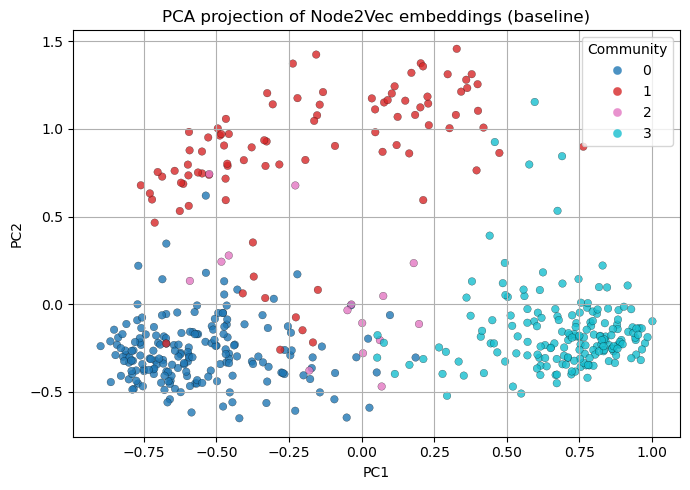

Explained variance ratio: [0.10482221 0.07004972]
Total explained variance: 0.17487192


In [49]:
# PCA visualization
best_config = results_df.loc[0, "config"]

X_emb = embeddings_by_config[best_config]
nodes_emb = nodes_by_config[best_config]
y_emb = np.array([community_dict[node] for node in nodes_emb])

print(X_emb.shape, len(y_emb))  # devono coincidere

pca_emb = PCA(n_components=2)
X_emb_2d = pca_emb.fit_transform(X_emb)

plt.figure(figsize=(7,5))

scatter = plt.scatter(
    X_emb_2d[:, 0],
    X_emb_2d[:, 1],
    c=y_emb,
    cmap="tab10",
    alpha=0.8,
    s=30,
    edgecolors="k",
    linewidths=0.2
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA projection of Node2Vec embeddings ({best_config})")
plt.legend(*scatter.legend_elements(), title="Community")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca_emb.explained_variance_ratio_)
print("Total explained variance:", pca_emb.explained_variance_ratio_.sum())

(475, 64) 475


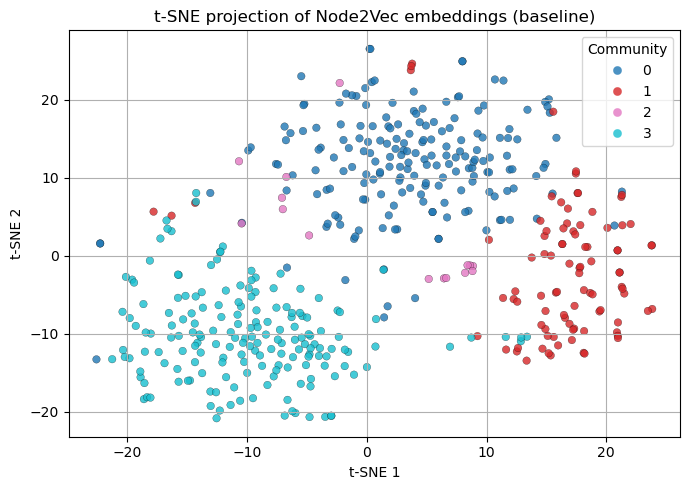

In [50]:
# tsne visualization
best_config = results_df.loc[0, "config"]

X_emb = embeddings_by_config[best_config]
nodes_emb = nodes_by_config[best_config]
y_emb = np.array([community_dict[node] for node in nodes_emb])

print(X_emb.shape, len(y_emb))  # devono coincidere

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_emb)

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_emb,
    cmap="tab10",
    alpha=0.8,
    s=30,
    edgecolors="k",
    linewidths=0.2
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title(f"t-SNE projection of Node2Vec embeddings ({best_config})")
plt.legend(*scatter.legend_elements(), title="Community")
plt.tight_layout()
plt.show()

The PCA projection already reveals a partial separation between communities, suggesting that the embeddings capture important structural information. The t-SNE visualization further highlights this pattern, producing clearly separated clusters corresponding to the detected communities. This confirms that the Node2Vec embeddings effectively encode the modular organization of the network.

## GDV Feature Extraction & Logistic Regression
To compute Graphlet Degree Vectors (GDV), we used the orbit-count library, which efficiently calculates the number of times each node participates in different graphlet orbits. Graphlets are small induced subgraphs that capture local connectivity patterns around a node.

Since the orbit-count package does not currently provide precompiled wheels for Windows, the GDV features were computed in a Google Colab environment. The undirected version of the network (G_und) was exported as an edge list, loaded in Colab, and processed using the node_orbit_counts function.

The resulting matrix contains, for each node, the counts of its participation in different graphlet orbits. These features were then saved to a CSV file and imported into the main notebook, where they were used as input features for the node classification task.

In [55]:
# Node classification using Graphlet Degree Vector (GDV) embeddings
# Predict the Louvain community labels using Logistic Regression

gdv_df = pd.read_csv("gdv_features.csv", index_col=0)
X_gdv = gdv_df.loc[nodes_ml].values

X_train_gdv = X_gdv[train_idx]
X_test_gdv = X_gdv[test_idx]

clf_gdv = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced")
)

clf_gdv.fit(X_train_gdv, y_train)
y_pred_gdv = clf_gdv.predict(X_test_gdv)

acc_gdv = accuracy_score(y_test, y_pred_gdv)
f1_macro_gdv = f1_score(y_test, y_pred_gdv, average="macro")
f1_weighted_gdv = f1_score(y_test, y_pred_gdv, average="weighted")

print("\n=== GDV results ===")
print(f"Accuracy     : {acc_gdv:.4f}")
print(f"F1 macro     : {f1_macro_gdv:.4f}")
print(f"F1 weighted  : {f1_weighted_gdv:.4f}")

gdv_report = classification_report(y_test, y_pred_gdv)
print("\n=== Classification report: GDV ===")
print(gdv_report)


=== GDV results ===
Accuracy     : 0.6923
F1 macro     : 0.6125
F1 weighted  : 0.7449

=== Classification report: GDV ===
              precision    recall  f1-score   support

           0       0.97      0.54      0.70        57
           1       0.68      0.82      0.74        28
           2       0.10      0.75      0.17         4
           3       0.91      0.78      0.84        54

    accuracy                           0.69       143
   macro avg       0.66      0.72      0.61       143
weighted avg       0.87      0.69      0.74       143



In [54]:
# GDV + centrality features
eigenvector = nx.eigenvector_centrality(G_und, max_iter=1000)
katz = nx.katz_centrality(G_und, alpha=0.01, beta=1.0, max_iter=1000)
pagerank = nx.pagerank(G_und)

# centrality features
centrality_df = pd.DataFrame({
    "degree": [G_und.degree(n) for n in nodes_ml],
    "eig": [eigenvector[n] for n in nodes_ml],
    "katz": [katz[n] for n in nodes_ml],
    "pg": [pagerank[n] for n in nodes_ml],
}, index=nodes_ml)

# combine GDV + centrality
feature_df = pd.concat(
    [gdv_df.loc[nodes_ml], centrality_df],
    axis=1
)

X_gdv_plus = feature_df.values

X_train_gdv_plus = X_gdv_plus[train_idx]
X_test_gdv_plus = X_gdv_plus[test_idx]

clf_gdv_plus = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced")
)

clf_gdv_plus.fit(X_train_gdv_plus, y_train)
y_pred_gdv_plus = clf_gdv_plus.predict(X_test_gdv_plus)

acc_gdv_plus = accuracy_score(y_test, y_pred_gdv_plus)
f1_macro_gdv_plus = f1_score(y_test, y_pred_gdv_plus, average="macro")
f1_weighted_gdv_plus = f1_score(y_test, y_pred_gdv_plus, average="weighted")

print("\n=== GDV + centrality results ===")
print(f"Accuracy     : {acc_gdv_plus:.4f}")
print(f"F1 macro     : {f1_macro_gdv_plus:.4f}")
print(f"F1 weighted  : {f1_weighted_gdv_plus:.4f}")


=== GDV + centrality results ===
Accuracy     : 0.7343
F1 macro     : 0.6444
F1 weighted  : 0.7824


To evaluate whether graphlet-based structural features capture meaningful information about node roles in the network, we perform node classification using Graphlet Degree Vector (GDV) embeddings. GDV features encode the local topology of each node by counting its participation in different graphlet orbit configurations.

Using a logistic regression classifier with balanced class weights, the model achieves an accuracy of 0.69 and a macro-F1 score of 0.61. The classifier successfully identifies the largest communities (0 and 3) with relatively high precision and recall, while it struggles when detecting nodes belonging to the smallest community (community 2).

To further enrich the structural representation, GDV features are combined with additional centrality measures (degree, eigenvector centrality, Katz centrality, and PageRank). The inclusion of these global structural indicators improves the results, increasing the accuracy to 0.73 and the macro-F1 score to 0.64, suggesting that combining local graphlet structure with global node importance provides a more informative representation of the network.

## Final Comparison

In [58]:
extra_results = [
    {
        "config": "gdv_only",
        "p": np.nan,
        "q": np.nan,
        "accuracy": acc_gdv,
        "f1_macro": f1_macro_gdv,
        "f1_weighted": f1_weighted_gdv
    },
    {
        "config": "gdv_plus_centrality",
        "p": np.nan,
        "q": np.nan,
        "accuracy": acc_gdv_plus,
        "f1_macro": f1_macro_gdv_plus,
        "f1_weighted": f1_weighted_gdv_plus
    }
]

comparison_df = pd.concat(
    [results_df, pd.DataFrame(extra_results)],
    ignore_index=True
).sort_values(
    by=["f1_macro", "accuracy"],
    ascending=False
).reset_index(drop=True)

print("\n=== Final comparison ===")
print(comparison_df)


=== Final comparison ===
                config    p    q  accuracy  f1_macro  f1_weighted
0             baseline  1.0  1.0  0.972028  0.944090     0.971625
1          bfs_like_q4  1.0  4.0  0.972028  0.939782     0.971616
2          bfs_like_q2  1.0  2.0  0.965035  0.937399     0.964586
3  gdv_plus_centrality  NaN  NaN  0.734266  0.644414     0.782382
4             gdv_only  NaN  NaN  0.692308  0.612498     0.744949


The final comparison shows that Node2Vec embeddings clearly outperform GDV-based representations in predicting node community membership. The best-performing configuration is the baseline Node2Vec model (p=1,q=1), which achieves a macro F1-score of approximately 0.94 and an accuracy of 0.97. These results indicate that the learned embeddings capture the community structure of the network very effectively.

This behavior is consistent with the nature of the Node2Vec algorithm. By generating biased random walks and training a skip-gram model, Node2Vec learns node representations that reflect network proximity and neighborhood similarity, which are strongly related to community structure. In this case, even the baseline random-walk setting is sufficient to encode the modular organization of the network with high accuracy.

In contrast, the GDV representation performs less effectively on this classification task. Using Graphlet Degree Vector features with balanced class weights, the model achieves a macro F1-score of about 0.61 and an accuracy of about 0.69. Although GDV captures detailed information about the local structural roles of nodes through graphlet orbit counts, it does not directly encode the broader connectivity patterns that define communities.

Combining GDV with additional centrality measures improves the results, raising the macro F1-score to about 0.64 and the accuracy to about 0.73. This suggests that enriching local graphlet-based information with more global structural indicators provides a more informative node representation. However, the performance still remains substantially below that of Node2Vec.

Overall, these findings highlight the advantage of representation learning approaches such as Node2Vec when the goal is to recover mesoscopic structures like communities. While GDV-based features provide useful information about local topology, community membership in this network is more effectively captured by embeddings based on node proximity and walk-based structural context.